In [ ]:
pip install ucimlrepo

In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, chi2, f_classif, f_regression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
def load_and_preprocess(file_path):

    # Load Dataset
    df = pd.read_csv(file_path)

    print("=" * 70)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 70)

    print("Shape :", df.shape)

    print("\nDataset Information")
    df.info()

    # Duplicate Rows
    duplicates = df.duplicated().sum()
    print("\nDuplicate Rows :", duplicates)

    df.drop_duplicates(inplace=True)

    # Remove Empty Rows and Columns
    df.dropna(axis=0, how="all", inplace=True)
    df.dropna(axis=1, how="all", inplace=True)

    # Replace Missing Value Symbols
    df.replace(
        ["?", "NA", "N/A", "na", "null", "NULL", ""],
        np.nan,
        inplace=True
    )

    # Remove Extra Spaces
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

    # Convert Numeric Strings
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")

    # Missing Value Percentage
    print("\nMissing Value Percentage")

    missing_percent = (df.isnull().sum() / len(df)) * 100
    print(missing_percent)

    # Drop Columns with More Than 50% Missing Values
    cols = missing_percent[missing_percent > 50].index

    if len(cols) > 0:
        print("\nDropped Columns :", list(cols))

    df.drop(columns=cols, inplace=True)

    # Fill Missing Values
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].fillna(df[col].median(), inplace=True)

        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

    # Remove Constant Columns
    constant_cols = []

    for col in df.columns:

        if df[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print("\nRemoved Constant Columns :", constant_cols)

    df.drop(columns=constant_cols, inplace=True)

    # Encode Categorical Columns
    categorical_cols = df.select_dtypes(include="object").columns

    encoder = LabelEncoder()

    for col in categorical_cols:
        df[col] = encoder.fit_transform(df[col])

    # Standardize Numerical Features
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if len(numeric_cols) > 1:

        feature_cols = numeric_cols[:-1]

        scaler = StandardScaler()

        df[feature_cols] = scaler.fit_transform(df[feature_cols])

    print("\nPreprocessing Completed Successfully")
    print("Final Shape :", df.shape)

    return df

In [5]:
pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
def perform_eda(df):

    print("=" * 70)
    print("DATASET SUMMARY")
    print("=" * 70)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nSummary Statistics")
    print(df.describe(include="all"))

    numeric_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns
    # Missing Values Heatmap
    plt.figure(figsize=(5, 3))
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
    plt.title("Missing Values Heatmap")
    plt.show()

    # Correlation Heatmap
    if len(numeric_cols) > 1:

        plt.figure(figsize=(5, 3))
        sns.heatmap(
            df[numeric_cols].corr(),
            annot=True,
            cmap="coolwarm"
        )
        plt.title("Correlation Heatmap")
        plt.show()

    # Histograms
    df[numeric_cols].hist(figsize=(9, 6))
    plt.suptitle("Histograms")
    plt.show()

    # Boxplots
    for col in numeric_cols:

        plt.figure(figsize=(4, 2))
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()

    # Scatter Plot
    if len(numeric_cols) >= 2:

        plt.figure(figsize=(3, 2))
        sns.scatterplot(
            x=df[numeric_cols[0]],
            y=df[numeric_cols[1]]
        )
        plt.title("Scatter Plot")
        plt.show()

    # Pair Plot
    if len(numeric_cols) <= 8:

        sns.pairplot(df[numeric_cols])
        plt.show()

    # Count Plots
    for col in categorical_cols:

        plt.figure(figsize=(5, 3))
        sns.countplot(x=df[col])
        plt.xticks(rotation=45)
        plt.title(col)
        plt.show()

    # Density Plots
    plt.figure(figsize=(7, 7))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(3, 3, i)   # 3 rows, 3 columns
        sns.kdeplot(df[col], fill=True)
        plt.title(col)

    plt.tight_layout()
    plt.show()


DATASET LOADED SUCCESSFULLY
Shape : (100000, 9)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Duplicate Rows : 3854

Missing Value Percentage
gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
smoking_history        0.0
bmi            

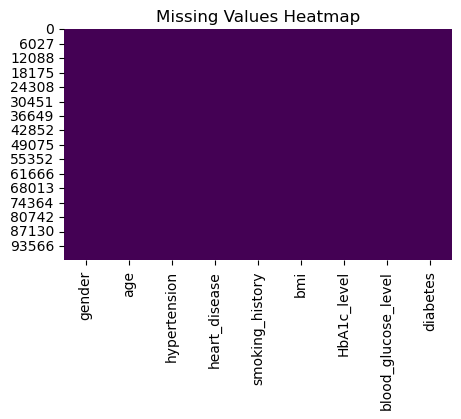

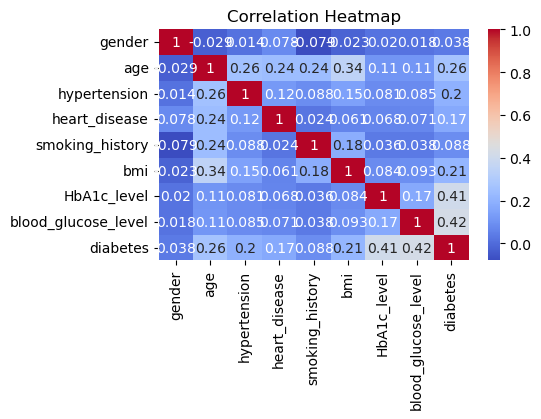

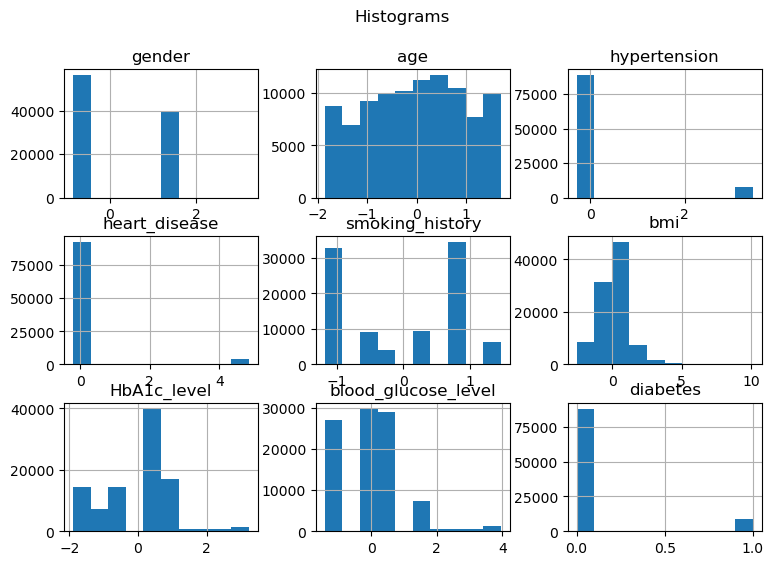

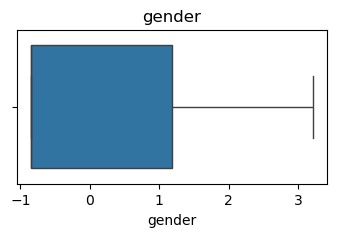

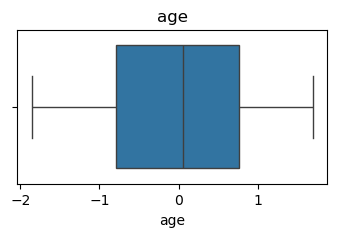

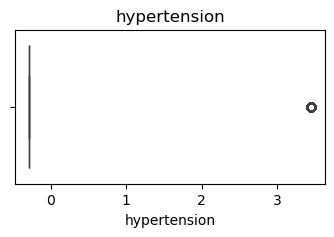

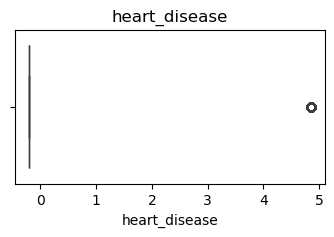

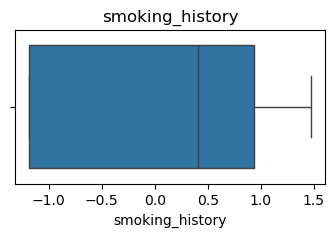

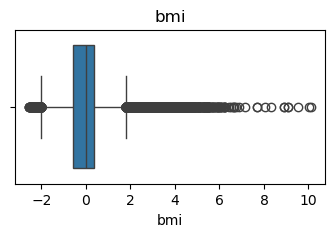

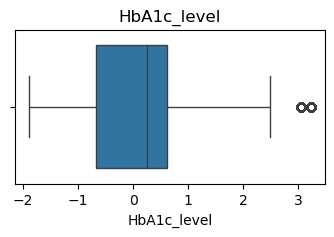

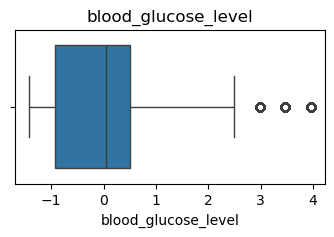

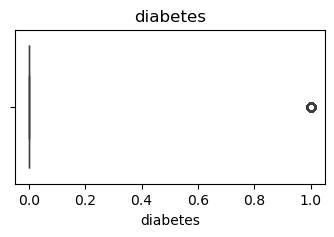

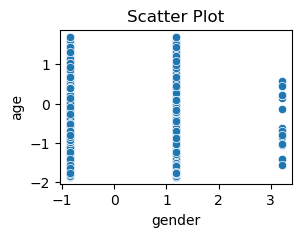

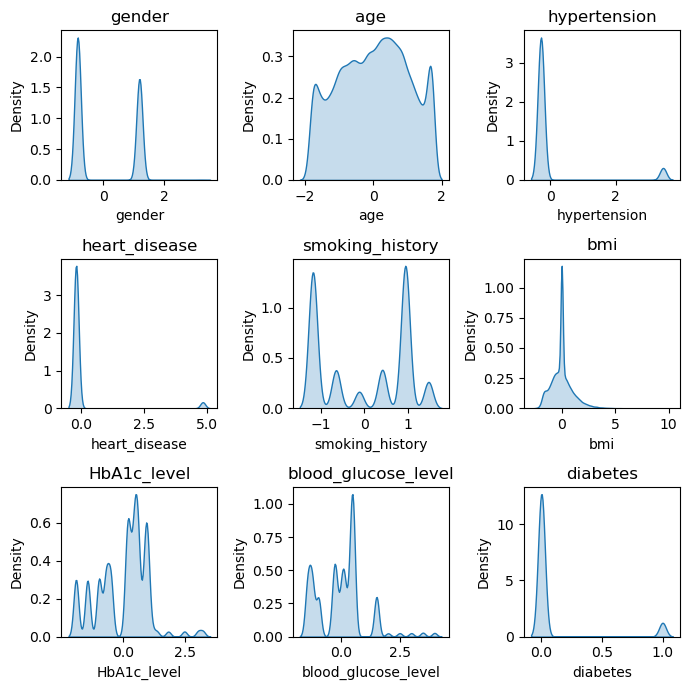

In [7]:
df=load_and_preprocess("/home/mtech1/Downloads/Exp1/diabetes/diabetes_prediction_dataset.csv")
print(df.head())
perform_eda(df)

In [ ]:
df1=load_and_preprocess("/home/mtech1/Downloads/Exp1/email/emails.csv")
print(df1.head())
perform_eda(df1)

In [ ]:
df2=load_and_preprocess("/home/mtech1/Downloads/Exp1/email/emails.csv")
print(df2.head())
perform_eda(df2)

In [11]:
def detect_task_type(df, target_col, classification_threshold=20):

    target = df[target_col]
    #we have as like object then cassification and less than 20 unique values in a row then classification else regression
    if target.dtype == "object" or target.nunique() <= classification_threshold:
        task = "classification"
    else:
        task = "regression"

    print(f"Target Column : {target_col}")
    print(f"Unique Values : {target.nunique()}")
    print(f"Detected Task : {task}")

    return task

In [13]:
def select_features(df, target_col, task=None, k=10, method="anova"):

    if task is None:
        task = detect_task_type(df, target_col)
    #finding classification or regression if not mentoned
    X = df.drop(columns=[target_col]) #only features no target element
    y = df[target_col]

    k = min(k, X.shape[1])

    if task == "classification":
        if method == "chi2":
            X_shifted = X - X.min()          # chi2 needs non-negative values
            selector = SelectKBest(score_func=chi2, k=k)
            selector.fit(X_shifted, y)
        else:
            selector = SelectKBest(score_func=f_classif, k=k) #anova-measures how well each feature separates the classes.
            selector.fit(X, y)
    else:
        selector = SelectKBest(score_func=f_regression, k=k)
        selector.fit(X, y)

    scores = pd.DataFrame({
        "Feature": X.columns,
        "Score": selector.scores_
    }).sort_values(by="Score", ascending=False)

    print("\nFeature Scores")
    print(scores)

    selected_cols = X.columns[selector.get_support()].tolist() # returns true/false for feature selected
    print("\nSelected Features :", selected_cols)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=scores, x="Score", y="Feature")
    plt.title("Feature Selection Scores")
    plt.show()

    return df[selected_cols + [target_col]], selected_cols

#train test validation wrt classification
def split_data(df, target_col, task=None, test_size=0.2, val_size=0.1, random_state=42):

    #stratify ensures he same percent split among train test validation data
    if task is None:
        task = detect_task_type(df, target_col)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    stratify = y if task == "classification" else None

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size),
        random_state=random_state, stratify=stratify
    )

    stratify_temp = y_temp if task == "classification" else None
    relative_val = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - relative_val),
        random_state=random_state, stratify=stratify_temp
    )

    print("Train :", X_train.shape)
    print("Val   :", X_val.shape)
    print("Test  :", X_test.shape)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [19]:
def train_and_evaluate(X_train, y_train, X_test, y_test, task=None):

    if task is None:
        task = "classification" if y_train.nunique() <= 20 else "regression"

    if task == "classification":
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(),
            "Random Forest": RandomForestClassifier(),
            "KNN": KNeighborsClassifier(),
            "SVM": SVC(probability=True),
            "Naive Bayes": GaussianNB()
        }
    else:
        models = {
            "Linear Regression": LinearRegression(),
            "Decision Tree": DecisionTreeRegressor(),
            "Random Forest": RandomForestRegressor(),
            "KNN": KNeighborsRegressor(),
            "SVR": SVR()
        }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if task == "classification":
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
            rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
            f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

            results.append([name, acc, prec, rec, f1])

            plt.figure(figsize=(5, 4))
            sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
            plt.title(f"Confusion Matrix - {name}")
            plt.show()

        else:
            mae = mean_absolute_error(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)

            results.append([name, mae, mse, rmse, r2])

            plt.figure(figsize=(5, 4))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
            plt.xlabel("Actual")
            plt.ylabel("Predicted")
            plt.title(f"Actual vs Predicted - {name}")
            plt.show()

    cols = ["Model", "Accuracy", "Precision", "Recall", "F1-Score"] if task == "classification" \
        else ["Model", "MAE", "MSE", "RMSE", "R2-Score"]

    results_df = pd.DataFrame(results, columns=cols)
    sort_col = cols[1]

    print("\nModel Comparison")
    print(results_df.sort_values(by=sort_col, ascending=(task == "regression")))

    return results_df

In [9]:
def run_ml_pipeline(file_path, target_col, task=None, k_features=10):

    df = load_and_preprocess(file_path)
    perform_eda(df)

    task = task or detect_task_type(df, target_col)

    df_selected, selected_cols = select_features(df, target_col, task=task, k=k_features)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_selected, target_col, task=task)

    results = train_and_evaluate(X_train, y_train, X_test, y_test, task=task)

    return results
#run_ml_pipeline("loandataset.csv", target_col="loan_amount")      # Regression

DATASET LOADED SUCCESSFULLY
Shape : (100000, 9)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Duplicate Rows : 3854

Missing Value Percentage
gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
smoking_history        0.0
bmi            

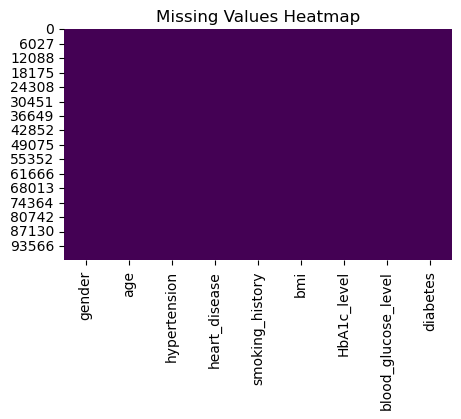

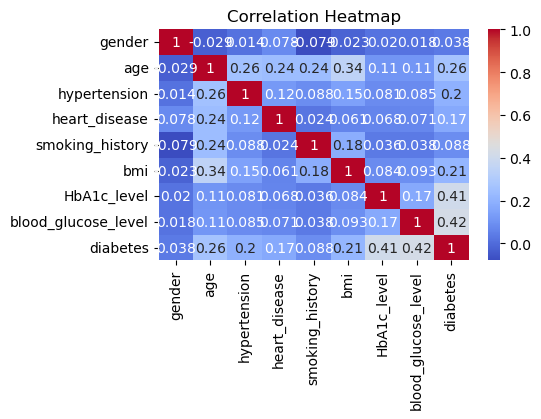

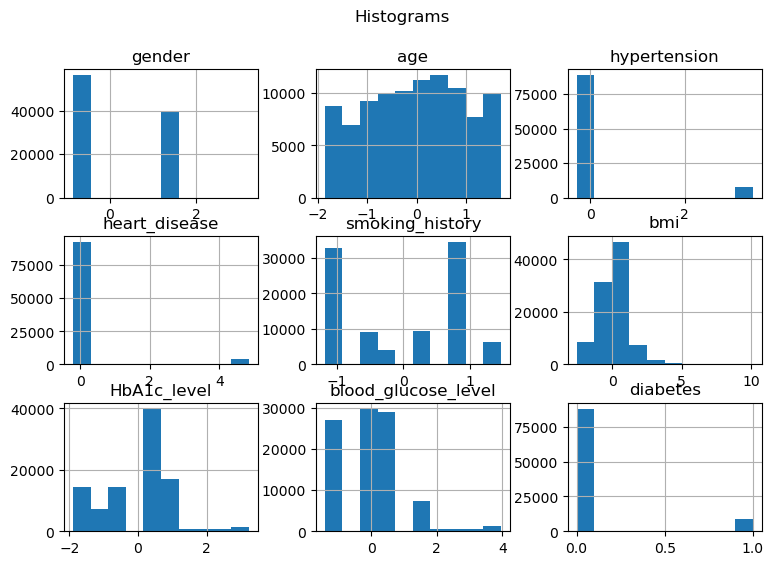

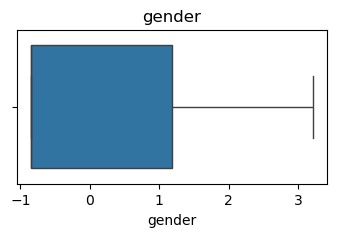

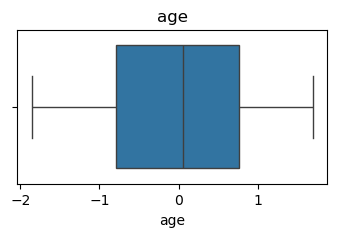

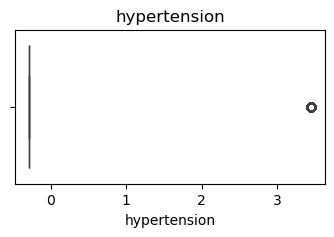

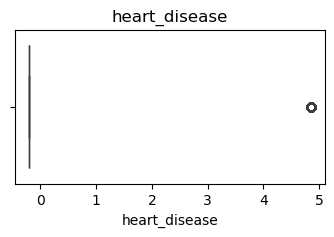

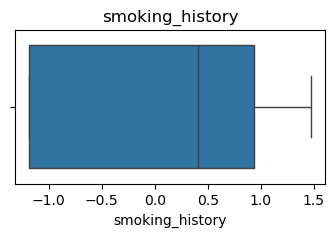

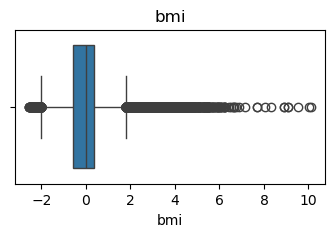

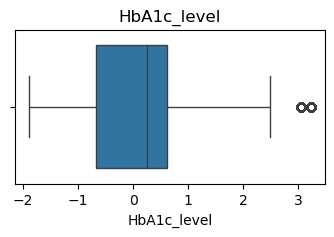

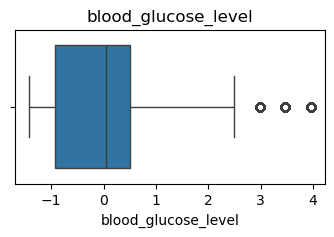

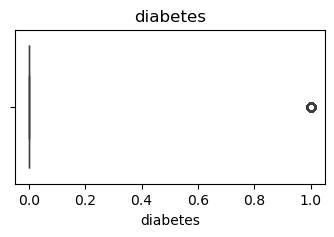

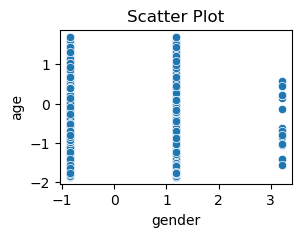

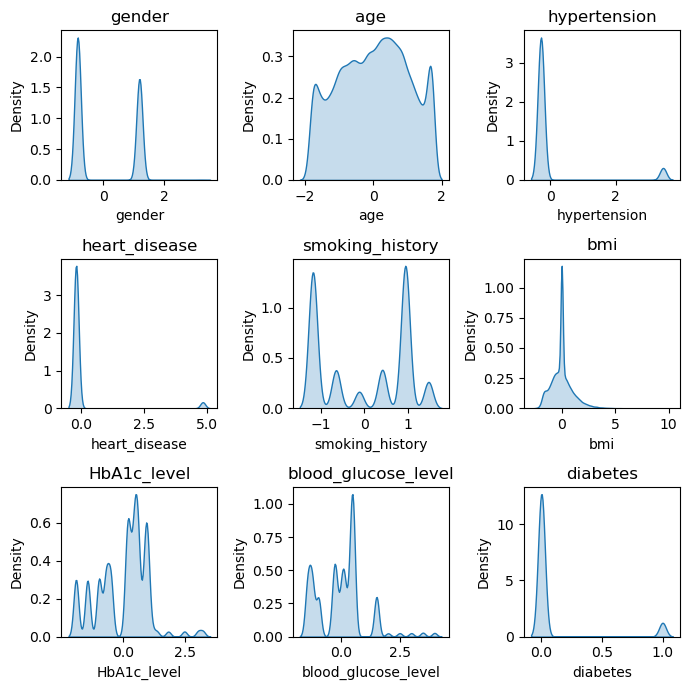

Target Column : diabetes
Unique Values : 2
Detected Task : classification

Feature Scores
               Feature         Score
7  blood_glucose_level  21113.489195
6          HbA1c_level  19021.654018
1                  age   7257.356029
5                  bmi   4656.545262
2         hypertension   3829.202325
3        heart_disease   2885.951707
4      smoking_history    758.464510
0               gender    136.211278

Selected Features : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']


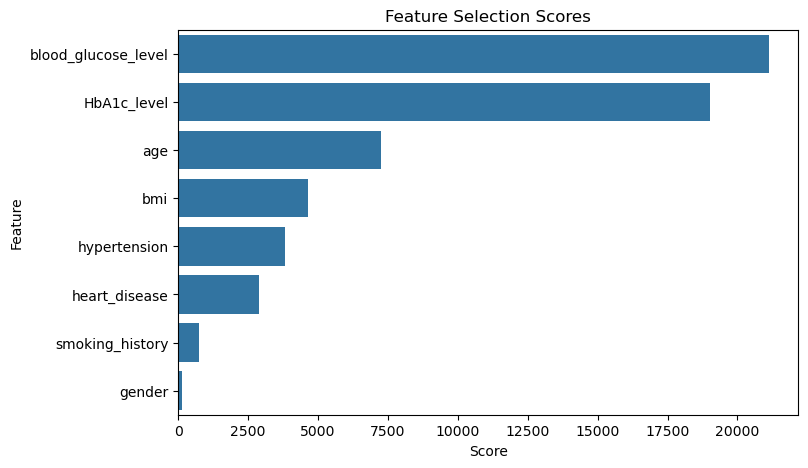

Train : (67302, 8)
Val   : (9614, 8)
Test  : (19230, 8)


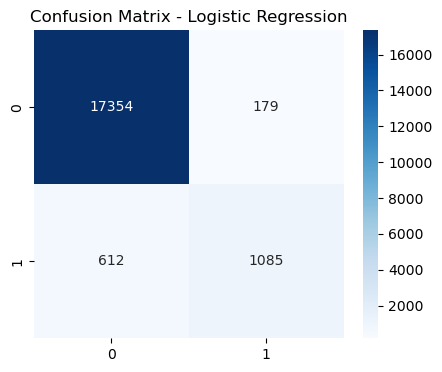

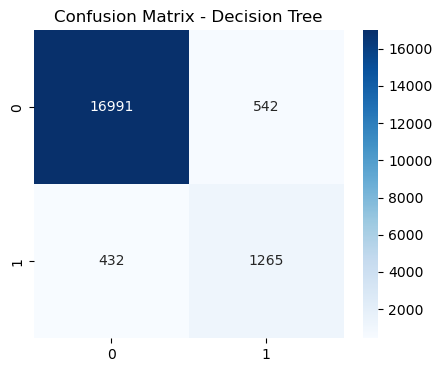

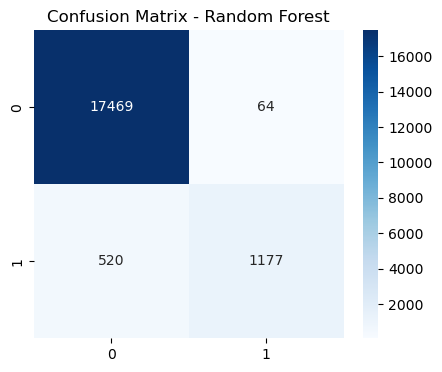

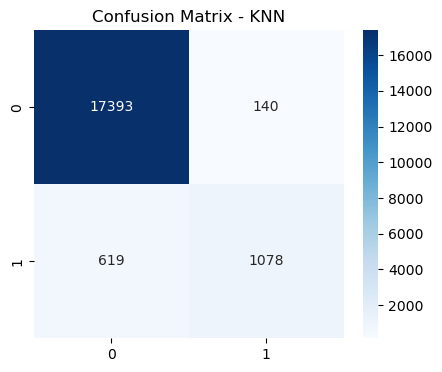

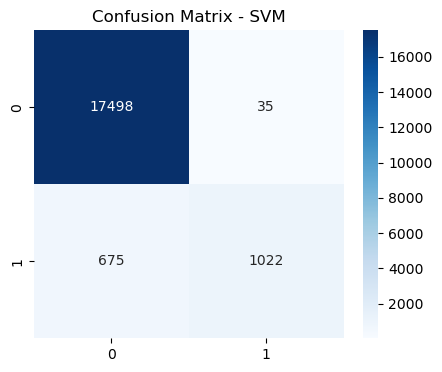

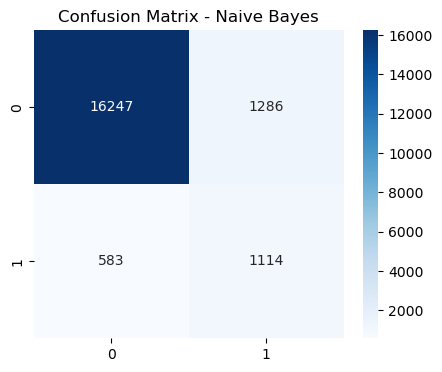


Model Comparison
                 Model  Accuracy  Precision    Recall  F1-Score
2        Random Forest  0.969631   0.969093  0.969631  0.967469
4                  SVM  0.963079   0.963213  0.963079  0.959119
3                  KNN  0.960530   0.958523  0.960530  0.957553
0  Logistic Regression  0.958866   0.956445  0.958866  0.956110
1        Decision Tree  0.949350   0.950924  0.949350  0.950065
5          Naive Bayes  0.902808   0.921130  0.902808  0.910152


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.958866,0.956445,0.958866,0.956110
1,Decision Tree,0.949350,0.950924,0.949350,0.950065
2,Random Forest,0.969631,0.969093,0.969631,0.967469
3,KNN,0.960530,0.958523,0.960530,0.957553
4,SVM,0.963079,0.963213,0.963079,0.959119
5,Naive Bayes,0.902808,0.921130,0.902808,0.910152


In [24]:
run_ml_pipeline("/home/mtech1/Downloads/Exp1/diabetes/diabetes_prediction_dataset.csv", target_col="diabetes")      